# Training Diagnostics Dashboard

Use this notebook to inspect the training-time metrics written to `models/train_metrics.jsonl` and the latest sampling diagnostics written to `data/processed/samples.diagnostics.json`.

This notebook is focused on diagnosing questions like:
- Is optimization healthy?
- Did the model plateau early?
- Is the model matching noise scale but still producing bad samples?
- Are sample-quality metrics improving over checkpoints?

In [28]:
import importlib
import sys
from pathlib import Path


def ensure_repo_on_path() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "pyproject.toml").exists() and (root / "polydiff").is_dir():
            root_str = str(root)
            if root_str not in sys.path:
                sys.path.insert(0, root_str)
            return root
    raise RuntimeError(
        "Could not locate repo root. Start Jupyter from this repo or install with: pip install -e .[dev]"
    )


REPO_ROOT = ensure_repo_on_path()

mod = sys.modules.get("polydiff")
if mod is not None:
    mod_file = Path(getattr(mod, "__file__", "") or "")
    if not mod_file.exists() or REPO_ROOT not in mod_file.parents:
        del sys.modules["polydiff"]

polydiff = importlib.import_module("polydiff")
print(f"repo root: {REPO_ROOT}")
print(f"polydiff module: {getattr(polydiff, '__file__', 'unknown')}")

repo root: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff
polydiff module: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/polydiff/__init__.py


In [29]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from polydiff import paths

plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:,.4f}".format

In [30]:
METRICS_PATH = paths.PROJECT_ROOT / "models/train_metrics.jsonl"
SAMPLE_DIAGNOSTICS_PATH = paths.PROJECT_ROOT / "data/processed/samples.diagnostics.json"
RUN_INDEX = -1  # -1 means latest appended run
ROLLING_WINDOW = 5

print(f"metrics path: {METRICS_PATH}")
print(f"sample diagnostics path: {SAMPLE_DIAGNOSTICS_PATH}")

if not METRICS_PATH.exists():
    raise FileNotFoundError(f"Missing metrics file: {METRICS_PATH}")

metrics path: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/models/train_metrics.jsonl
sample diagnostics path: /Users/jeremyzay/Desktop/thayer_lab_research/2026/spring_2026/polydiff/data/processed/samples.diagnostics.json


In [31]:
def load_jsonl_records(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


def split_training_runs(records: list[dict[str, object]]) -> list[list[dict[str, object]]]:
    runs: list[list[dict[str, object]]] = []
    current: list[dict[str, object]] = []
    last_step: int | None = None

    for record in records:
        event = record.get("event")
        if event == "train_start":
            if current:
                runs.append(current)
            current = [record]
            last_step = None
            continue

        if event == "train_step":
            step = int(record["step"])
            if last_step is not None and step < last_step:
                runs.append(current)
                current = [record]
            else:
                current.append(record)
            last_step = step
            continue

        current.append(record)

    if current:
        runs.append(current)
    return runs


def run_overview_frame(runs: list[list[dict[str, object]]]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for run_id, run in enumerate(runs):
        start = next((r for r in run if r.get("event") == "train_start"), {})
        end = next((r for r in run if r.get("event") == "train_end"), {})
        steps = [r for r in run if r.get("event") == "train_step"]
        rows.append(
            {
                "run_id": run_id,
                "num_train_steps_logged": len(steps),
                "first_step": None if not steps else int(steps[0]["step"]),
                "last_step": None if not steps else int(steps[-1]["step"]),
                "device": start.get("device"),
                "data_path": start.get("data_path"),
                "final_checkpoint": end.get("final_checkpoint"),
            }
        )
    return pd.DataFrame(rows)


def train_step_frame(run: list[dict[str, object]]) -> pd.DataFrame:
    steps = [r for r in run if r.get("event") == "train_step"]
    if not steps:
        return pd.DataFrame()
    return pd.DataFrame(steps).sort_values("step").reset_index(drop=True)


def sample_diagnostic_frame(run: list[dict[str, object]]) -> pd.DataFrame:
    records = [r for r in run if r.get("event") == "sample_diagnostic"]
    if not records:
        return pd.DataFrame()

    rows: list[dict[str, object]] = []
    for record in records:
        row = {
            "epoch": int(record["epoch"]),
            "step": int(record["step"]),
            "num_samples": int(record["num_samples"]),
            "n_steps": int(record["n_steps"]),
        }
        for key, value in record.get("sample_summary", {}).items():
            row[f"sample.{key}"] = value
        for key, value in record.get("delta_vs_training", {}).items():
            row[f"delta.{key}"] = value
        rows.append(row)
    return pd.DataFrame(rows).sort_values("step").reset_index(drop=True)


def rolling_mean(values: pd.Series, window: int) -> pd.Series:
    return values.rolling(window=window, min_periods=1).mean()


def load_json_file(path: Path) -> dict[str, object] | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())

## Run Selection

The training metrics file can contain multiple appended runs. This section lets you confirm which run you are looking at before you interpret the graphs.

How to interpret it:
- If `num_train_steps_logged` is smaller than expected, the run may have stopped early.
- If you see multiple runs, keep `RUN_INDEX = -1` to inspect the latest one or set it to a specific `run_id`.
- `last_step` should roughly match the checkpoint step reported in the sampling diagnostics if you sampled from the final checkpoint of that run.

In [32]:
records = load_jsonl_records(METRICS_PATH)
runs = split_training_runs(records)
run_table = run_overview_frame(runs)
selected_run = runs[RUN_INDEX]
train_df = train_step_frame(selected_run)
sample_diag_df = sample_diagnostic_frame(selected_run)
latest_sampling_report = load_json_file(SAMPLE_DIAGNOSTICS_PATH)

print(f"selected run index: {RUN_INDEX if RUN_INDEX >= 0 else len(runs) - 1}")
run_table

selected run index: 18


,run_id,num_train_steps_logged,first_step,last_step,device,data_path,final_checkpoint
0,0,111,0,5500,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
1,1,111,0,5500,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
2,2,111,0,5500,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
3,3,111,0,5500,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
4,4,48,0,2350,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
5,5,95,0,4700,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
6,6,95,0,4700,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
7,7,95,0,4700,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
8,8,237,0,11800,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...
9,9,237,0,11800,cpu,/Users/jeremyzay/Desktop/thayer_lab_research/2...,/Users/jeremyzay/Desktop/thayer_lab_research/2...


## Loss And Denoising Curves

These are the first graphs to look at for optimization health.

How to interpret them:
- `loss` is noisy batch-to-batch; `ema_loss` is the smoother trend to trust.
- `x0_pred_mse` is a more task-relevant denoising proxy than raw noise MSE alone. If it drops sharply and then plateaus, the model may be learning the easy part and stalling.
- If both curves flatten while sample quality is still bad, the bottleneck is likely the model or diffusion recipe rather than optimizer instability.
- If the curves are still clearly falling at the end, more training may still help.

Typical healthy pattern:
- A steep drop early, then slower improvement later.
- Noise in the raw curve is fine; large upward drift in `ema_loss` is not.

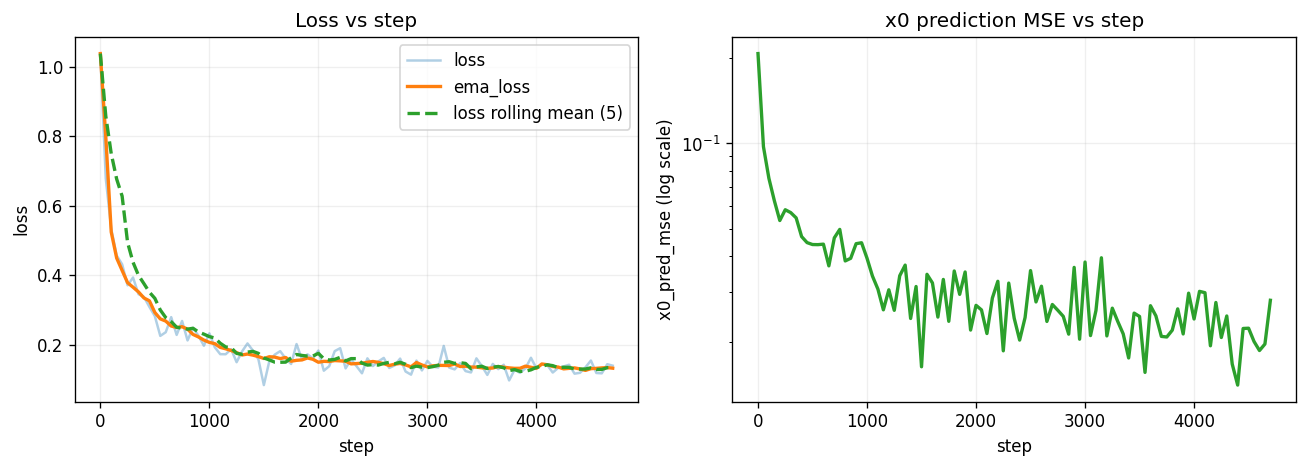

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

axes[0].plot(train_df["step"], train_df["loss"], alpha=0.35, label="loss")
axes[0].plot(train_df["step"], train_df["ema_loss"], linewidth=2, label="ema_loss")
axes[0].plot(
    train_df["step"],
    rolling_mean(train_df["loss"], ROLLING_WINDOW),
    linewidth=2,
    linestyle="--",
    label=f"loss rolling mean ({ROLLING_WINDOW})",
)
axes[0].set_title("Loss vs step")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(train_df["step"], train_df["x0_pred_mse"], linewidth=2, color="tab:green")
axes[1].set_yscale("log")
axes[1].set_title("x0 prediction MSE vs step")
axes[1].set_xlabel("step")
axes[1].set_ylabel("x0_pred_mse (log scale)")
axes[1].grid(alpha=0.2)

fig.tight_layout()

## Stability And Noise-Scale Tracking

These plots tell you whether the training dynamics themselves look broken.

How to interpret them:
- `grad_norm`: large persistent spikes can mean instability; very tiny values for long periods can mean stalled learning.
- `param_norm`: smooth upward drift is normal; sudden blow-ups are not.
- `eps_pred_std` vs `noise_std`: the model's predicted noise scale should move toward the actual noise scale. If `eps_pred_std` stays far below `noise_std`, the model is under-denoising.
- `t_mean`: with uniform timestep sampling and `n_steps=1000`, it should stay around the middle of the schedule. Large bias here would indicate a bug in timestep sampling.

Typical healthy pattern:
- Stable gradient norms, slowly growing parameter norm, and `eps_pred_std` approaching `noise_std`.

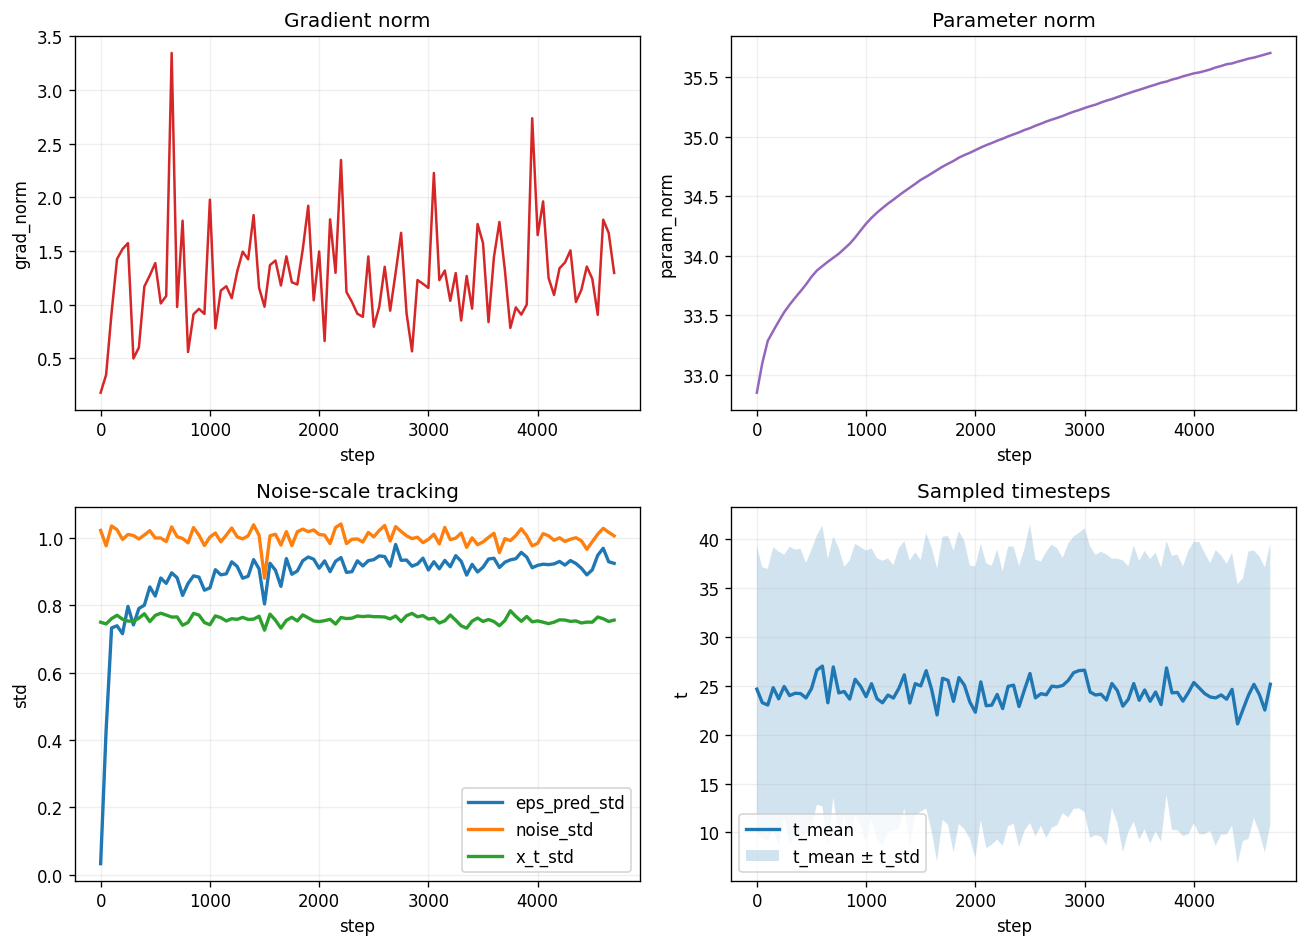

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.0))
axes = axes.reshape(-1)

axes[0].plot(train_df["step"], train_df["grad_norm"], color="tab:red")
axes[0].set_title("Gradient norm")
axes[0].set_xlabel("step")
axes[0].set_ylabel("grad_norm")
axes[0].grid(alpha=0.2)

axes[1].plot(train_df["step"], train_df["param_norm"], color="tab:purple")
axes[1].set_title("Parameter norm")
axes[1].set_xlabel("step")
axes[1].set_ylabel("param_norm")
axes[1].grid(alpha=0.2)

axes[2].plot(train_df["step"], train_df["eps_pred_std"], linewidth=2, label="eps_pred_std")
axes[2].plot(train_df["step"], train_df["noise_std"], linewidth=2, label="noise_std")
axes[2].plot(train_df["step"], train_df["x_t_std"], linewidth=2, label="x_t_std")
axes[2].set_title("Noise-scale tracking")
axes[2].set_xlabel("step")
axes[2].set_ylabel("std")
axes[2].legend()
axes[2].grid(alpha=0.2)

axes[3].plot(train_df["step"], train_df["t_mean"], linewidth=2, label="t_mean")
axes[3].fill_between(
    train_df["step"],
    train_df["t_mean"] - train_df["t_std"],
    train_df["t_mean"] + train_df["t_std"],
    alpha=0.2,
    label="t_mean ± t_std",
)
axes[3].set_title("Sampled timesteps")
axes[3].set_xlabel("step")
axes[3].set_ylabel("t")
axes[3].legend()
axes[3].grid(alpha=0.2)

fig.tight_layout()

## Sample-Quality Diagnostics

This section is the most important one for generated-sample quality.

How to interpret it:
- If `sample_diagnostic` events were logged during training, you want their deltas to move toward zero over checkpoint step.
- `score_mean_delta` near zero is good. Strongly negative means generated polygons are still too irregular.
- Positive `edge/angle/radius_cv` deltas mean the model is systematically missing local regularity.
- If there are no in-training sample diagnostics, the fallback bar chart from `samples.diagnostics.json` still tells you the latest failure mode, but not when it emerged.

Typical healthy pattern:
- Over training, the score delta rises toward zero and the CV deltas fall toward zero.

No sample_diagnostic events were logged during this run.
Showing the latest sampling diagnostics file instead. To get time-series curves, enable sample_diagnostics_every in the training config.


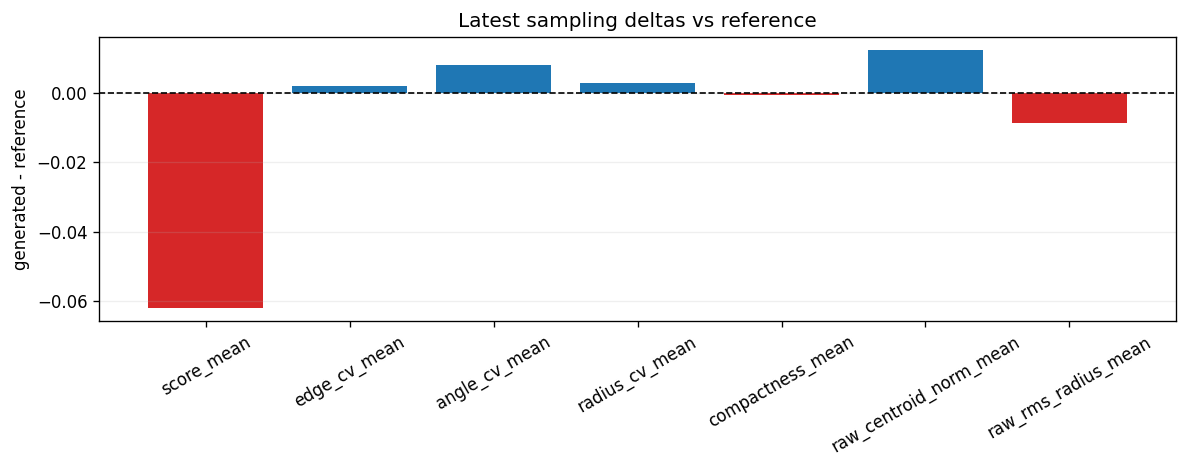

In [35]:
if not sample_diag_df.empty:
    delta_cols = [
        "delta.score_mean_delta",
        "delta.edge_cv_mean_delta",
        "delta.angle_cv_mean_delta",
        "delta.radius_cv_mean_delta",
        "delta.compactness_mean_delta",
    ]
    fig, axes = plt.subplots(len(delta_cols), 1, figsize=(8.5, 2.8 * len(delta_cols)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, delta_cols):
        ax.plot(sample_diag_df["step"], sample_diag_df[col], marker="o")
        ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(col.replace("delta.", "").replace("_", " "))
        ax.set_ylabel("delta")
        ax.grid(alpha=0.2)
    axes[-1].set_xlabel("checkpoint step")
    fig.tight_layout()
else:
    print("No sample_diagnostic events were logged during this run.")
    print("Showing the latest sampling diagnostics file instead. To get time-series curves, enable sample_diagnostics_every in the training config.")

    if latest_sampling_report is None:
        print("No samples.diagnostics.json file found.")
    else:
        deltas = latest_sampling_report.get("delta_vs_reference", {})
        bar_keys = [
            "score_mean_delta",
            "edge_cv_mean_delta",
            "angle_cv_mean_delta",
            "radius_cv_mean_delta",
            "compactness_mean_delta",
            "raw_centroid_norm_mean_delta",
            "raw_rms_radius_mean_delta",
        ]
        labels = [key.replace("_delta", "") for key in bar_keys if key in deltas]
        values = [deltas[key] for key in bar_keys if key in deltas]
        colors = ["tab:red" if value < 0 else "tab:blue" for value in values]

        fig, ax = plt.subplots(figsize=(10.0, 4.0))
        ax.bar(labels, values, color=colors)
        ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
        ax.set_title("Latest sampling deltas vs reference")
        ax.set_ylabel("generated - reference")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(axis="y", alpha=0.2)
        fig.tight_layout()

## Quick Diagnostic Summary

This table and note block are meant to answer: did training keep improving, or did it mostly plateau?

How to interpret it:
- Compare the early and late means. Big early gains with tiny late gains mean the run is saturating.
- If `eps_pred_std / noise_std` is still far below `1`, the model is underpredicting noise amplitude.
- If sample deltas are still large while the training metrics plateau, the recipe or model is likely the main bottleneck rather than simple optimizer instability.

In [36]:
summary_rows = []
first = train_df.iloc[:10]
middle = train_df.iloc[max(len(train_df) // 2 - 5, 0): min(len(train_df) // 2 + 5, len(train_df))]
last = train_df.iloc[-10:]

for metric in ["loss", "ema_loss", "x0_pred_mse", "grad_norm", "eps_pred_std", "noise_std"]:
    summary_rows.append(
        {
            "metric": metric,
            "first10_mean": float(first[metric].mean()),
            "middle10_mean": float(middle[metric].mean()),
            "last10_mean": float(last[metric].mean()),
            "last_minus_first": float(last[metric].mean() - first[metric].mean()),
        }
    )

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

eps_ratio = float(last["eps_pred_std"].mean() / last["noise_std"].mean())
print(f"latest eps_pred_std / noise_std ratio: {eps_ratio:.3f}")

if latest_sampling_report is not None and latest_sampling_report.get("delta_vs_reference") is not None:
    delta = latest_sampling_report["delta_vs_reference"]
    print(f"latest score_mean_delta: {delta.get('score_mean_delta', float('nan')):+.4f}")
    print(f"latest edge_cv_mean_delta: {delta.get('edge_cv_mean_delta', float('nan')):+.4f}")
    print(f"latest angle_cv_mean_delta: {delta.get('angle_cv_mean_delta', float('nan')):+.4f}")
    print(f"latest radius_cv_mean_delta: {delta.get('radius_cv_mean_delta', float('nan')):+.4f}")

,metric,first10_mean,middle10_mean,last10_mean,last_minus_first
0,loss,0.4895,0.1510,0.1328,-0.3567
1,ema_loss,0.4982,0.1503,0.1318,-0.3664
2,x0_pred_mse,0.0759,0.0266,0.0207,-0.0551
3,grad_norm,0.9515,1.2611,1.3323,0.3807
4,eps_pred_std,0.6628,0.9226,0.9246,0.2618
5,noise_std,1.0091,1.0053,0.9987,-0.0103


latest eps_pred_std / noise_std ratio: 0.926
latest score_mean_delta: -0.0622
latest edge_cv_mean_delta: +0.0022
latest angle_cv_mean_delta: +0.0083
latest radius_cv_mean_delta: +0.0031
